# 04 — K-Means Clustering & Segment Labeling

**Goal:** fit the final K=4 model, profile each cluster in real (un-transformed) RFM terms, and turn arbitrary cluster numbers into business-readable segment names -- via a reproducible rule, not a hardcoded guess.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm = pd.read_csv("../data/rfm.csv")
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,14646,2,73,280206.02
1,18102,1,60,259657.30
2,17450,9,46,194550.79
3,16446,1,2,168472.50
4,14911,2,201,143825.06


## 1. Prep features exactly as in the elbow notebook (log Frequency/Monetary, then scale)

In [2]:
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

features = ["Recency", "Frequency_log", "Monetary_log"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])

## 2. Fit K-Means with K=4

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm["Cluster"].value_counts().sort_index()

Cluster
0     574
1    1449
2     938
3    1377
Name: count, dtype: int64

## 3. Profile each cluster on the ORIGINAL (un-logged) scale

This is what actually gets read by a human -- real days, real order counts, real pounds.

In [4]:
cluster_summary = rfm.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    CustomerCount=("CustomerID", "count"),
).round(1)

cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,20.3,15.8,9801.3,574
1,46.6,4.2,1649.8,1449
2,259.9,1.4,386.8,938
3,58.6,1.5,386.4,1377


## 4. Rank clusters -> assign business labels

Rank each cluster on all three dimensions (lower rank = better), sum the ranks, then sort. Lowest total = best overall = Champions; highest total = worst overall = Lost. This rule is driven by each cluster's actual behavior, so it still works correctly even if `random_state` or the data changes and the raw cluster numbers land differently.

In [5]:
rank_df = pd.DataFrame({
    "recency_rank": cluster_summary["Recency"].rank(ascending=True),    # low recency = good = rank 1
    "frequency_rank": cluster_summary["Frequency"].rank(ascending=False),  # high frequency = good = rank 1
    "monetary_rank": cluster_summary["Monetary"].rank(ascending=False),    # high monetary = good = rank 1
})
rank_df["total_score"] = rank_df.sum(axis=1)
rank_df = rank_df.sort_values("total_score")

segment_order = ["Champions", "Loyal Customers", "At-Risk", "Lost"]
segment_map = dict(zip(rank_df.index, segment_order))

print(rank_df)
print()
print("Cluster -> Segment mapping:", segment_map)

         recency_rank  frequency_rank  monetary_rank  total_score
Cluster                                                          
0                 1.0             1.0            1.0          3.0
1                 2.0             2.0            2.0          6.0
3                 3.0             3.0            4.0         10.0
2                 4.0             4.0            3.0         11.0

Cluster -> Segment mapping: {0: 'Champions', 1: 'Loyal Customers', 3: 'At-Risk', 2: 'Lost'}


In [6]:
rfm["Segment"] = rfm["Cluster"].map(segment_map)

segment_profile = rfm.groupby("Segment").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Customers=("CustomerID", "count"),
).round(1)
segment_profile["% of Customers"] = (segment_profile["Customers"] / len(rfm) * 100).round(1)
segment_profile = segment_profile.loc[segment_order]
segment_profile

,Recency,Frequency,Monetary,Customers,% of Customers
Segment,,,,,
Champions,20.3,15.8,9801.3,574,13.2
Loyal Customers,46.6,4.2,1649.8,1449,33.4
At-Risk,58.6,1.5,386.4,1377,31.7
Lost,259.9,1.4,386.8,938,21.6


## 5. Revenue concentration check

The single most important sentence in the whole project: what % of customers drive what % of revenue?

In [7]:
total_revenue = rfm["Monetary"].sum()
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().loc[segment_order]
segment_revenue_pct = (segment_revenue / total_revenue * 100).round(1)

for seg in segment_order:
    pct_customers = segment_profile.loc[seg, "% of Customers"]
    pct_revenue = segment_revenue_pct[seg]
    print(f"{seg:18s}: {pct_customers:5.1f}% of customers -> {pct_revenue:5.1f}% of revenue")

Champions         :  13.2% of customers ->  63.1% of revenue
Loyal Customers   :  33.4% of customers ->  26.8% of revenue
At-Risk           :  31.7% of customers ->   6.0% of revenue
Lost              :  21.6% of customers ->   4.1% of revenue


## 6. Visualize: Recency vs Monetary, colored by segment

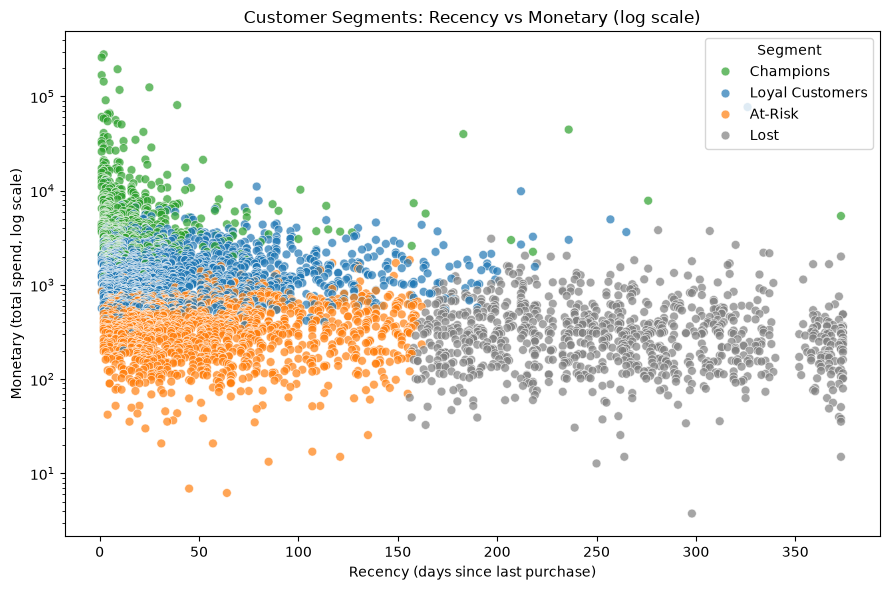

In [8]:
palette = {
    "Champions": "#2ca02c",
    "Loyal Customers": "#1f77b4",
    "At-Risk": "#ff7f0e",
    "Lost": "#7f7f7f",
}

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Segment",
    hue_order=segment_order, palette=palette, alpha=0.7, s=40,
)
plt.yscale("log")
plt.title("Customer Segments: Recency vs Monetary (log scale)")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary (total spend, log scale)")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("../outputs/segment_scatter.png", dpi=150)
plt.show()

## 7. Bring in Country for the geographic view

`rfm.csv` doesn't carry `Country` (it's a per-transaction field, dropped during SQL/pandas aggregation since RFM is purely behavioral). For the dashboard's country breakdown, pull each customer's most frequent `Country` from the cleaned transaction log -- a customer occasionally has more than one country logged (edge case in the raw data), so we take the mode, not just the first row.

In [9]:
tx = pd.read_csv("../data/cleaned_transactions.csv", usecols=["CustomerID", "Country"])
country_per_customer = (
    tx.groupby("CustomerID")["Country"]
    .agg(lambda s: s.mode().iat[0])
    .reset_index()
)
country_per_customer["CustomerID"] = country_per_customer["CustomerID"].astype(int)

rfm = rfm.merge(country_per_customer, on="CustomerID", how="left")
rfm["Country"].value_counts().head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               29
Belgium             24
Switzerland         20
Portugal            19
Italy               14
Finland             12
Norway              10
Name: count, dtype: int64

## 7. Save final outputs for the dashboard

In [10]:
rfm_out = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment", "Country"]]
rfm_out.to_csv("../outputs/rfm_table.csv", index=False)

segment_profile.reset_index().to_csv("../outputs/segment_summary.csv", index=False)

print("Saved outputs/rfm_table.csv and outputs/segment_summary.csv")
rfm_out.head()

Saved outputs/rfm_table.csv and outputs/segment_summary.csv


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Country
0,14646,2,73,280206.02,0,Champions,Netherlands
1,18102,1,60,259657.30,0,Champions,United Kingdom
2,17450,9,46,194550.79,0,Champions,United Kingdom
3,16446,1,2,168472.50,0,Champions,United Kingdom
4,14911,2,201,143825.06,0,Champions,EIRE


## Takeaways

- Cluster labels came from a **reproducible ranking rule** (sum of Recency/Frequency/Monetary ranks), not a hardcoded lookup on this run's arbitrary cluster numbers.
- `outputs/rfm_table.csv` -- one row per customer, ready to import into Power BI as the fact table.
- `outputs/segment_summary.csv` -- one row per segment, ready for KPI cards / bar charts.
- `outputs/segment_scatter.png` -- static proof the 4 segments are visually distinct, not just a metrics table.

**Next up:** import `rfm_table.csv` into Power BI and build the interactive dashboard (scatter, bar charts, KPI cards, segment/country slicers).